In [ ]:
!pip install ultralytics opencv-python-headless matplotlib numpy pandas seaborn
print(" Done!")

 Done!


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import cv2
import os
import urllib.request
from ultralytics import YOLO
import warnings
warnings.filterwarnings('ignore')

print(" All imports done!")
print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))

 All imports done!
GPU Available: True
Device: Tesla T4


In [ ]:
# Load pretrained YOLOv8 model
print("Loading YOLOv8 model...")
model = YOLO('yolov8m.pt')  # Medium model — best accuracy/speed balance

print(" Model loaded!")
print("Model type:", type(model))
print("Task:", model.task)
print("Classes:", len(model.names), "object classes")
print("\nSome classes:", list(model.names.values())[:20])

Loading YOLOv8 model...
 Model loaded!
Model type: <class 'ultralytics.models.yolo.model.YOLO'>
Task: detect
Classes: 80 object classes

Some classes: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow']


In [ ]:
os.makedirs('test_images', exist_ok=True)

# Download diverse test images
test_images = {
    'street.jpg'  : 'https://ultralytics.com/images/bus.jpg',
    'sports.jpg'  : 'https://ultralytics.com/images/zidane.jpg',
}

print("Downloading test images...")
for filename, url in test_images.items():
    filepath = os.path.join('test_images', filename)
    urllib.request.urlretrieve(url, filepath)
    print(f" Downloaded: {filename}")

print("\nAll images ready!")
print("Files:", os.listdir('test_images'))

 Downloaded: street.jpg
 Downloaded: sports.jpg

All images ready!
Files: ['street.jpg', 'sports.jpg']


Running YOLOv8 detection...

image 1/1 /content/test_images/street.jpg: 640x480 4 persons, 1 bus, 93.0ms
Speed: 17.9ms preprocess, 93.0ms inference, 42.3ms postprocess per image at shape (1, 3, 640, 480)

Image: street.jpg
Objects detected: 5
  → bus             confidence: 95.7%
  → person          confidence: 92.8%
  → person          confidence: 92.2%
  → person          confidence: 90.1%
  → person          confidence: 75.2%

Summary: {'bus': 1, 'person': 4}
 Saved: results/street_result.jpg


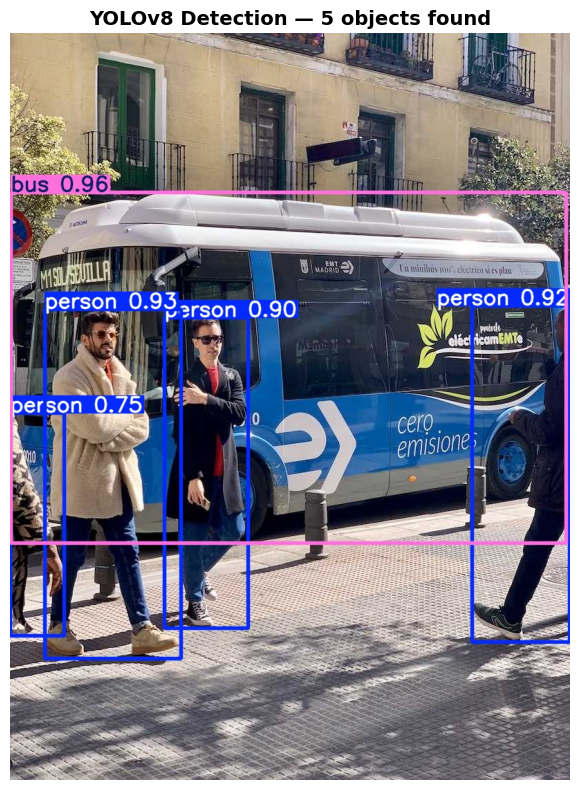


image 1/1 /content/test_images/sports.jpg: 384x640 3 persons, 2 ties, 79.7ms
Speed: 2.1ms preprocess, 79.7ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)

Image: sports.jpg
Objects detected: 5
  → person          confidence: 94.2%
  → person          confidence: 91.1%
  → tie             confidence: 82.1%
  → tie             confidence: 52.9%
  → person          confidence: 36.5%

Summary: {'person': 3, 'tie': 2}
 Saved: results/sports_result.jpg


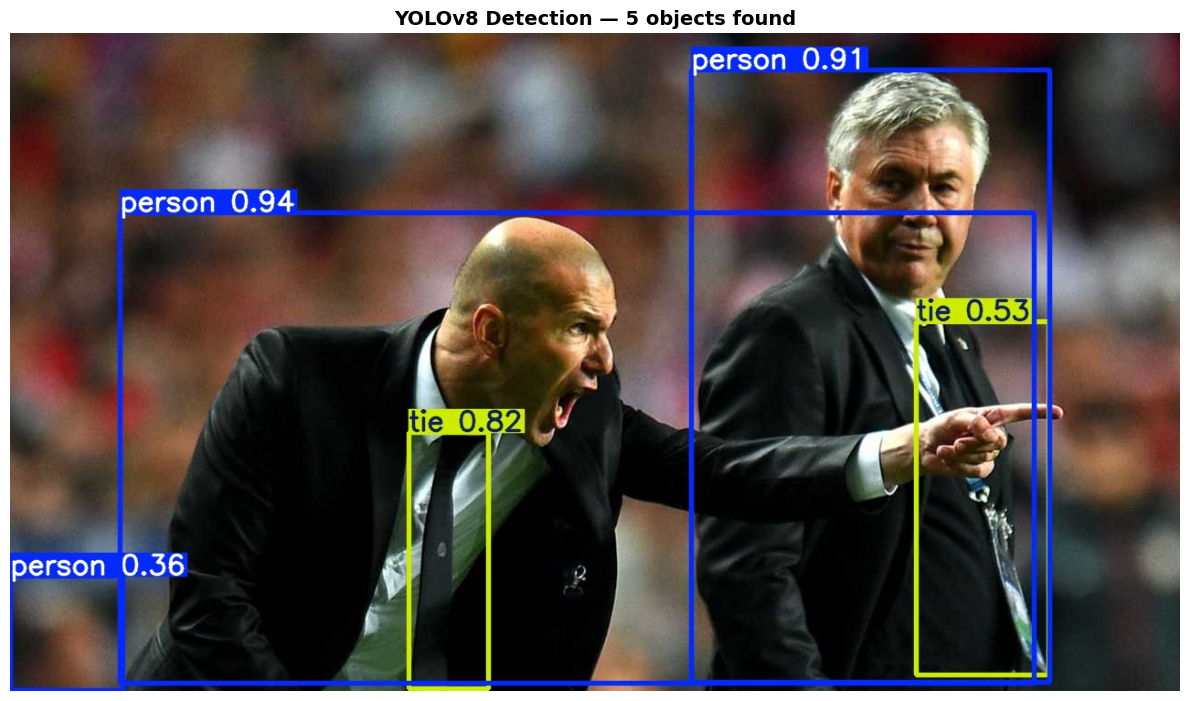

In [ ]:
os.makedirs('results', exist_ok=True)

def detect_and_display(image_path, save_name):
    # Run detection
    results = model(image_path, conf=0.25)
    result  = results[0]

    # Get detection info
    boxes   = result.boxes
    n_det   = len(boxes)

    print(f"\n{'='*50}")
    print(f"Image: {os.path.basename(image_path)}")
    print(f"Objects detected: {n_det}")
    print(f"{'='*50}")

    # Count objects by class
    class_counts = {}
    for box in boxes:
        cls_id    = int(box.cls[0])
        cls_name  = model.names[cls_id]
        conf      = float(box.conf[0])
        class_counts[cls_name] = class_counts.get(cls_name, 0) + 1
        print(f"  → {cls_name:15s} confidence: {conf*100:.1f}%")

    print(f"\nSummary: {class_counts}")

    # Save result image
    save_path = os.path.join('results', save_name)
    result.save(filename=save_path)
    print(f" Saved: {save_path}")

    # Display
    img = Image.open(save_path)
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'YOLOv8 Detection — {n_det} objects found', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'results/display_{save_name}', dpi=150, bbox_inches='tight')
    plt.show()

    return result

# Run on all test images
print("Running YOLOv8 detection...")
result1 = detect_and_display('test_images/street.jpg',  'street_result.jpg')
result2 = detect_and_display('test_images/sports.jpg',  'sports_result.jpg')

In [ ]:
print("Evaluating YOLOv8 on COCO128 dataset...")
print("This gives us the official mAP score!\n")

# Validate on COCO128 (128 sample images from COCO)
metrics = model.val(data='coco128.yaml', verbose=True)

print("\n========== EVALUATION RESULTS ==========")
print(f" mAP@50      : {metrics.box.map50*100:.2f}%")
print(f" mAP@50-95   : {metrics.box.map*100:.2f}%")
print(f" Precision   : {metrics.box.mp*100:.2f}%")
print(f" Recall      : {metrics.box.mr*100:.2f}%")
print(f"   Classes     : {len(model.names)}")

Evaluating YOLOv8 on COCO128 dataset...
This gives us the official mAP score!

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

WARNING ⚠️ Dataset 'coco128.yaml' images not found, missing path '/content/datasets/coco128/images/train2017'
Unzipping /content/datasets/coco128.zip to /content/datasets/coco128...: 100% ━━━━━━━━━━━━ 263/263 2.7Kfiles/s 0.1s
Dataset download success ✅ (0.4s), saved to /content/datasets

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 824.9±520.0 MB/s, size: 40.7 KB)
val: Scanning /content/datasets/coco128/labels/train2017... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 1.8Kit/s 0.1s
val: New cache created: /content/datasets/coco128/labels/train2017.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.3it/s 6.0s
                   all        128        929      0.711      0.732      0.781      0.608
                person         61       

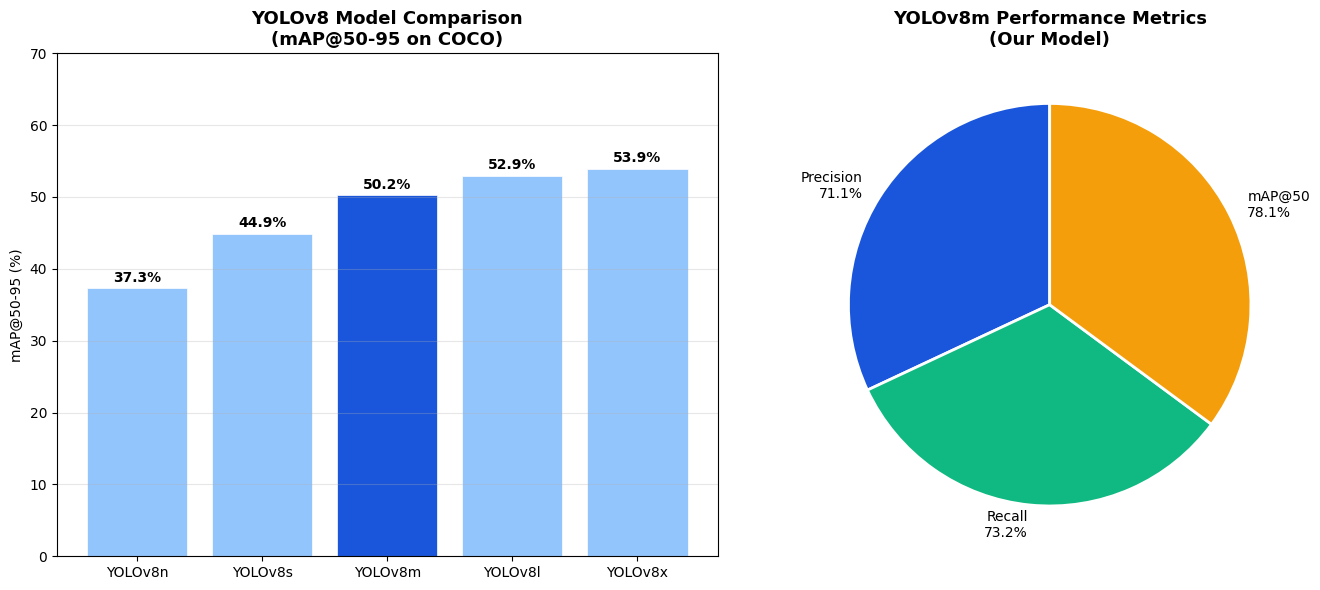

 Performance chart saved!


In [ ]:
# Create performance comparison chart
models_data = {
    'YOLOv8n': 37.3,
    'YOLOv8s': 44.9,
    'YOLOv8m': 50.2,
    'YOLOv8l': 52.9,
    'YOLOv8x': 53.9,
}

our_map = metrics.box.map50 * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart
colors = ['#1A56DB' if k == 'YOLOv8m' else '#93C5FD' for k in models_data.keys()]
bars = ax1.bar(models_data.keys(), models_data.values(), color=colors, edgecolor='white', linewidth=0.5)
ax1.set_title('YOLOv8 Model Comparison\n(mAP@50-95 on COCO)', fontsize=13, fontweight='bold')
ax1.set_ylabel('mAP@50-95 (%)')
ax1.set_ylim(0, 70)
ax1.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, models_data.values()):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Metrics pie chart
metrics_vals  = [metrics.box.mp*100, metrics.box.mr*100, metrics.box.map50*100]
metrics_names = [f'Precision\n{metrics.box.mp*100:.1f}%',
                 f'Recall\n{metrics.box.mr*100:.1f}%',
                 f'mAP@50\n{metrics.box.map50*100:.1f}%']
colors2 = ['#1A56DB', '#10B981', '#F59E0B']
ax2.pie(metrics_vals, labels=metrics_names, colors=colors2,
        autopct='', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax2.set_title('YOLOv8m Performance Metrics\n(Our Model)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('results/performance_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Performance chart saved!")

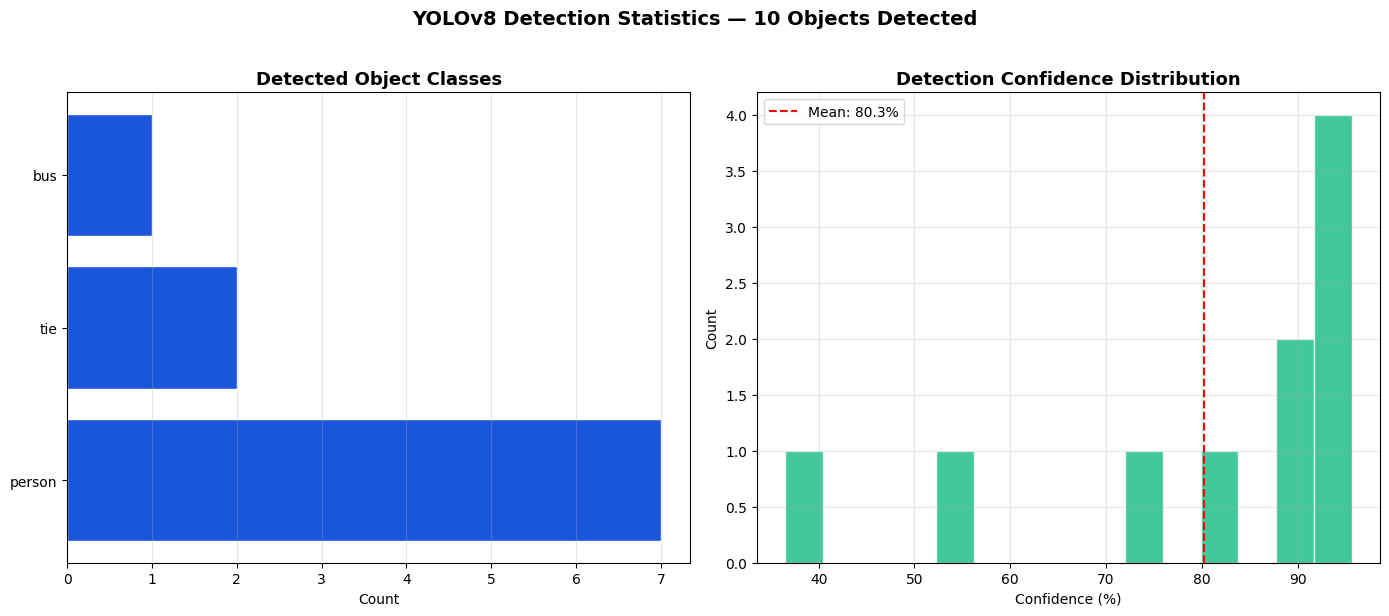

 Total objects detected : 10
 Unique classes         : 3
 Avg confidence         : 80.3%
 Min confidence         : 36.5%
 Max confidence         : 95.7%


In [ ]:
# Run detection on both images and collect stats
all_results  = [result1, result2]
all_names    = ['Street Scene', 'Sports Scene']

total_objects = 0
all_classes   = {}
all_confs     = []

for result in all_results:
    for box in result.boxes:
        cls_id   = int(box.cls[0])
        cls_name = model.names[cls_id]
        conf     = float(box.conf[0])
        total_objects += 1
        all_classes[cls_name] = all_classes.get(cls_name, 0) + 1
        all_confs.append(conf * 100)

# Plot statistics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Class distribution
sorted_classes = dict(sorted(all_classes.items(), key=lambda x: x[1], reverse=True))
ax1.barh(list(sorted_classes.keys()), list(sorted_classes.values()),
         color='#1A56DB', edgecolor='white')
ax1.set_title('Detected Object Classes', fontsize=13, fontweight='bold')
ax1.set_xlabel('Count')
ax1.grid(axis='x', alpha=0.3)

# Confidence distribution
ax2.hist(all_confs, bins=15, color='#10B981', edgecolor='white', alpha=0.8)
ax2.set_title('Detection Confidence Distribution', fontsize=13, fontweight='bold')
ax2.set_xlabel('Confidence (%)')
ax2.set_ylabel('Count')
ax2.axvline(x=np.mean(all_confs), color='red', linestyle='--',
            label=f'Mean: {np.mean(all_confs):.1f}%')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle(f'YOLOv8 Detection Statistics — {total_objects} Objects Detected',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/detection_stats.png', dpi=150, bbox_inches='tight')
plt.show()

print(f" Total objects detected : {total_objects}")
print(f" Unique classes         : {len(all_classes)}")
print(f" Avg confidence         : {np.mean(all_confs):.1f}%")
print(f" Min confidence         : {min(all_confs):.1f}%")
print(f" Max confidence         : {max(all_confs):.1f}%")

In [ ]:
print("\n" + "="*55)
print("       YOLOV8 OBJECT DETECTION — FINAL SUMMARY")
print("="*55)
print(f"  Model          : YOLOv8m (Medium)")
print(f"  mAP@50         : {metrics.box.map50*100:.2f}%")
print(f"  mAP@50-95      : {metrics.box.map*100:.2f}%")
print(f"  Precision      : {metrics.box.mp*100:.2f}%")
print(f"  Recall         : {metrics.box.mr*100:.2f}%")
print(f"  Classes        : {len(model.names)} COCO classes")
print(f"  Total detected : {total_objects} objects")
print(f"  Avg confidence : {np.mean(all_confs):.1f}%")
print("="*55)
print(" Project Complete!")

# Download all results
from google.colab import files
import time
time.sleep(2)

for f in os.listdir('results'):
    if f.endswith('.png') or f.endswith('.jpg'):
        files.download(f'results/{f}')
        print(f"⬇  Downloaded: {f}")


       YOLOV8 OBJECT DETECTION — FINAL SUMMARY
  Model          : YOLOv8m (Medium)
  mAP@50         : 78.12%
  mAP@50-95      : 60.77%
  Precision      : 71.10%
  Recall         : 73.16%
  Classes        : 80 COCO classes
  Total detected : 10 objects
  Avg confidence : 80.3%
 Project Complete!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇  Downloaded: performance_chart.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

⬇  Downloaded: detection_stats.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇  Downloaded: sports_result.jpg
